In [16]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

In [18]:
adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()

ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [19]:
adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs.loc[adata_raw.obs_names, 'palantir_pseudotime']

In [20]:
if os.path.exists('data/tom_pos_raw_impute_X.npy'):

    print("tom_pos_raw_impute_X.npy exists")
    impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
    adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload


else:
    print("tom_pos_raw_impute_X.npy does not exist")
    impute_x = palantir.utils.run_magic_imputation(adata_raw)
    np.save("data/tom_pos_raw_impute_X.npy", impute_x)

tom_pos_raw_impute_X.npy exists


In [21]:
for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = ad_palantir.obsm[key].copy()

for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = ad_palantir.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = ad_palantir.obs['palantir_pseudotime'].copy()

impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

In [22]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

for lineage in ['Neu', 'Meg', 'Ery']:
    ad = adata_raw[adata_raw.obsm['branch_masks'][lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime
    x = np.linspace(0, pdt_max, 100)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.project_params_to_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    g_project[lineage] = tl.project_params_to_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, 21)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=20,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.3  0.62 0.25 0.39 0.35 0.48 0.21 0.44 0.16 0.53 0.58 0.76 0.71 0.85
 0.67 0.9  0.81 0.12 0.07 0.02]
[0.39 0.34 0.31 0.37 0.28 0.42 0.45 0.47 0.26 0.53 0.5  0.23 0.18 0.15
 0.2  0.09 0.12 0.07 0.04 0.01]
[0.24 0.29 0.59 0.2  0.55 0.37 0.33 0.64 0.42 0.51 0.46 0.15 0.68 0.73
 0.81 0.77 0.86 0.11 0.07 0.02]


In [23]:
def find_steepest_region(x_values, rate_values,  min_bins=10):
    """
    Identify the pseudotime region with steepest slope
    
    Parameters:
    x_values: dict with pseudotime bins per lineage
    rate_values: dict with rate values (v or g) per lineage
    day_idx : int, the index to select which day of the paramter to use
    min_bins: minimum number of consecutive bins to consider
    
    Returns: dict with steepest region info per lineage
    """
    steepest_regions = {}
    

    # Calculate slopes using central differences
    dx = np.diff(x_values)[0]  # Assuming uniform spacing
    slopes = np.gradient(rate_values, dx)
    
    # Calculate absolute slopes for windowed analysis
    window_size = min_bins
    mean_abs_slopes = np.array([
        np.mean(np.abs(slopes[i:i+window_size]))
        for i in range(len(slopes) - window_size + 1)
    ])
    
    # Find window with maximum mean absolute slope
    max_idx = np.argmax(mean_abs_slopes)
    start_bin = x_values[max_idx]
    end_bin = x_values[max_idx + window_size - 1]
    
    steepest_regions = {
        'start_bin': start_bin,
        'end_bin': end_bin,
        'mean_slope': mean_abs_slopes[max_idx],
        'window_idx': (max_idx, max_idx + window_size)
    }
    
    return steepest_regions

def find_steepest_region(x_values, rate_values, day_idx, min_bins=10):
    """
    Identify the pseudotime region with steepest slope
    
    Parameters:
    x_values: dict with pseudotime bins per lineage
    rate_values: dict with rate values (v or g) per lineage
    day_idx : int, the index to select which day of the paramter to use
    min_bins: minimum number of consecutive bins to consider
    
    Returns: dict with steepest region info per lineage
    """
    steepest_regions = {}
    
    for lineage in x_values.keys():
        # Calculate slopes using central differences
        dx = np.diff(x_values[lineage])[0]  # Assuming uniform spacing
        slopes = np.gradient(rate_values[lineage][day_idx], dx)
        
        # Calculate absolute slopes for windowed analysis
        window_size = min_bins
        mean_abs_slopes = np.array([
            np.mean(np.abs(slopes[i:i+window_size]))
            for i in range(len(slopes) - window_size + 1)
        ])
        
        # Find window with maximum mean absolute slope
        max_idx = np.argmax(mean_abs_slopes)
        start_bin = x_values[lineage][max_idx]
        end_bin = x_values[lineage][max_idx + window_size - 1]
        
        steepest_regions[lineage] = {
            'start_bin': start_bin,
            'end_bin': end_bin,
            'mean_slope': mean_abs_slopes[max_idx],
            'window_idx': (max_idx, max_idx + window_size)
        }
    
    return steepest_regions

In [24]:
np.gradient(v_project['Neu'][7], np.diff(x_project["Neu"])[0]).shape

(99,)

In [25]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from de_test import fitGAM, run_fitGAM_parallel

In [26]:
def get_input(adata_lin, lineage):
    """
    prepare input for fitGAM
    """
    ad = adata_lin[lineage]
    cell_time = ad.obs["palantir_pseudotime"].values
    if 'MAGIC_imputed_data' in ad.layers:
        expression_matrix = ad.layers['MAGIC_imputed_data'].A.copy()
    else:
        expression_matrix = ad.X.A.copy()
    
    genes = ad.var_names.values
    
    return expression_matrix, cell_time, genes

In [ ]:
for lineage in ['Ery', 'Meg', 'Neu']:
    expression_matrix, cell_time, genes = get_input(adata_lin, lineage)

    # Run parallel GAM fitting
    # it takes around 7 minutes
    gam_fit2 = run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
    de_test.save_gamfit(gam_fit2, save_dir=f'results/tompos_{lineage}_GAM/')

# new Associtation Test

In [27]:
# from importlib import reload
# reload(de_test)
import de_test

# select genes 

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
from statsmodels.stats.multitest import multipletests

def select_top_de_genes(results_df, qval_threshold=0.05):
    """
    Select top differentially expressed genes based on p-value threshold
    
    Parameters:
    results_df: DataFrame with association test results
    qval_threshold: p-value threshold for selecting DE genes
    
    Returns: list of gene indices passing threshold
    """
    # Filter significant genes
    significant = results_df[~results_df['pvalue'].isna()]
    significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]
    
    # Sort by Wald statistic
    significant = significant.query("`fdr` <= @qval_threshold").sort_values('waldStat', ascending=False)
    
    return significant


def scaled_GAM_smooth_expression(expr_df):
    # Process each gene
    scaler = MinMaxScaler()

    for i, gene in enumerate(expr_df.columns):
        expr = expr_df[gene].values
        expr_df[gene] = scaler.fit_transform(expr.reshape(-1, 1)).flatten()
    
    return expr_df

def prepare_expression_data(gam_fit, pseudotime=None):
    """
    Prepare and scale gene expression data for plotting
    
    Parameters:
    gam_fit: fitted GAM models
    pseudotime: optional custom pseudotime points
    
    Returns: DataFrame with scaled expression values
    """
    if pseudotime is None:
        # Create prediction grid
        pseudotime = gam_fit['pseudotime']
        pred_grid = np.linspace(pseudotime.min(), pseudotime.max(), 100)
        pseudotime = pred_grid
    
    
    # Process each gene
    scaler = MinMaxScaler()
    
    Expr_list = []
    gene_symbol = []
    for i, gene_idx in enumerate(gam_fit['gene_names']):
        model_info = gam_fit['models'][gene_idx]
        
        # Get prediction function
        if model_info['model']:
            pred = model_info['pred_func'](pseudotime)
            scaled_pred = scaler.fit_transform(pred.reshape(-1, 1)).flatten()
            Expr_list.append(scaled_pred)
            gene_symbol.append(gam_fit['gene_symbol'][i])
        else:
            continue
            
        # Get predictions
        
        # Initialize DataFrame
        expr_df = pd.DataFrame(np.stack(Expr_list).T, columns=gene_symbol)
        expr_df.index = pseudotime
    
    return expr_df

In [29]:
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression

def calculate_mutual_information(
    parameter: np.ndarray,
    predicted_expression: np.ndarray,
    n_neighbors: int = 3,
    random_state: int = 42
) -> float:
    """
    Calculate mutual information between a parameter and predicted expression.
    
    Parameters:
        parameter (np.ndarray): Parameter values (e.g., pseudotime)
        predicted_expression (np.ndarray): Predicted expression values from GAM model
        n_neighbors (int): Number of neighbors to use for MI estimation
        random_state (int): Random state for reproducibility
        
    Returns:
        float: Mutual information value
    """
    # Ensure proper shape
    if parameter.ndim == 1:
        parameter = parameter.reshape(-1, 1)
        
    # Calculate mutual information
    mi = mutual_info_regression(
        parameter,
        predicted_expression,
        n_neighbors=n_neighbors,
        random_state=random_state
    )
    
    return float(mi[0])

In [30]:
mmTF = pd.read_csv("data/mouse_geneset/allTFs_mm.txt", sep='\t',  names=['gene_symbol'])

steepest_region_Day3 = find_steepest_region(x_project, v_project, 0, min_bins=30)
steepest_region_Day7 = find_steepest_region(x_project, v_project, 1, min_bins=30)
steepest_region_Day161 = find_steepest_region(x_project, v_project, 7, min_bins=30)

### igonore

<font size=2>  

```python
for lineage in ['Neu', 'Meg', 'Ery']:

    print(f"\nprocessing {lineage}")
    print("loading GAM model")
    
    gam_fit = de_test.load_gamfit(f'results/tompos_{lineage}_GAM/')
    
    print("preparing and scaling gene trends")
    lineage_expr_df = prepare_expression_data(gam_fit, pseudotime=x_project[lineage])
    lineage_expr_df.to_csv(f"results/tompos_{lineage}_GAM/GAM_scaled_expression.csv", index=True)

    # lineage_expr_df = lineage_expr_df.iloc[3:-3]

    for day_id in [0, 1, 7]:

        day = adata_raw.uns['pop']['t'][day_id]
        print(f"== processing Day {day} ==")

        steepest_region = find_steepest_region(x_project, v_project, day_id)
        pseudotime_range = (steepest_region[lineage]['start_bin'], 
                        steepest_region[lineage]['end_bin'])

        # # Run association tests
        test = de_test.AssociationTest(gam_fit, ['lineage'])
        result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
        result_lin_day['gene_symbol'] = gam_fit['gene_symbol']

        result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

        # select significantly DE genes and annotate TF
        significant_genes = select_top_de_genes(result_lin_day, qval_threshold=1e-2)
        significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
        significant_genes.set_index("gene_symbol", inplace=True)

        # compute parameter derivative
        dx = x_project[lineage][0]
        drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

        # compute correlation and mutual information
        corr_list = [pearsonr(lineage_expr_df.loc[:,gene].values[3:-3], drift_derivatives[3:-3])[0] for gene in significant_genes.index]
        mi_list = [calculate_mutual_information(lineage_expr_df.loc[:,gene].values[3:-3], drift_derivatives[3:-3]) for gene in significant_genes.index]

        significant_genes['pearson_r'] = corr_list
        significant_genes['mutual_information'] = mi_list

        significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)
```

</font>

In [22]:
sig_TFs = significant_genes.query("`meanLogFC`>1 & `mutual_information`>0.7 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
s = significant_genes.query("`meanLogFC`>2 & `pearson_r` > 0" ).sort_values("mutual_information", ascending=False)

NameError: name 'significant_genes' is not defined

# visualization

In [38]:
from itertools import cycle
import seaborn as sns
import matplotlib.pyplot as plt

def plot_de_genes_with_rate(
    expr_df, 
    steepest_region, 
    lineage='Neu', 
    day_idx=0,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,    # Assuming this is available from notebook
    ax=None
    ):
    """
    Plot scaled expression of DE genes with rate information
    
    Parameters:
    ------
    expr_df: DataFrame with scaled expression data
    steepest_region: dict with steepest region info
    lineage: cell lineage to plot
    day_idx: index of timepoint to show rate
    ax: optional matplotlib axes to plot on
    
    Returns: 
    ------
    matplotlib axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    
    # Create color and line style combinations
    colors = sns.color_palette()  # Get current Seaborn color palette
    linestyles = ['-', '--', '-.', ':']  # Available line styles
    
    # Create all possible combinations of color and line style
    style_cycle = cycle([(color, linestyle) for linestyle in linestyles for color in colors ])
    
    # Plot gene expression profiles
    genes = expr_df.columns.to_list()
    expr_dpt = expr_df.index.to_numpy()
    
    # Store legend elements
    legend_elements = []
    
    for col in genes:
        color, linestyle = next(style_cycle)
        line = ax.plot(
            expr_dpt,
            expr_df[col],
            color=color,
            linestyle=linestyle,
            alpha=0.7,
            label=f'{col.split("_")[-1]}'
        )
        # Add to legend elements
        legend_elements.append(plt.Line2D([0], [0], color=color, linestyle=linestyle, label=f'{col.split("_")[-1]}'))
    
    # Add rate information on secondary axis
    ax2 = ax.twinx()
    
    # Get rate data
    rate_values = v_project[lineage][day_idx]
    rate_pseudotime = x_project[lineage]

    mask = np.logical_and(rate_pseudotime<=expr_dpt.max(), rate_pseudotime>=expr_dpt.min())
    
    # Plot rate
    rate_line = ax2.plot(
        rate_pseudotime[mask],
        rate_values[mask],
        color='navy',
        linewidth=2,
        linestyle='--',
        label=f'Rate (Day {day_idx})'
    )
    
    # Highlight steepest slope region
    start_bin = steepest_region[lineage]['start_bin']
    end_bin = steepest_region[lineage]['end_bin']
    
    ax.axvspan(
        start_bin, 
        end_bin, 
        alpha=0.2, 
        color='gray',
        label='Steepest Slope Region'
    )
    
    # Formatting
    ax.set_title('Scaled Expression of Top DE Genes with Rate Profile')
    ax.set_xlabel('Pseudotime')
    ax.set_ylabel('Scaled Expression')
    ax2.set_ylabel('Rate Value', color='navy')
    
    # Combine legends
    lines1 = legend_elements
    lines2 = [plt.Line2D([0], [0], color='navy', linewidth=2, linestyle='--', label=f'Rate (Day {day_idx})')]
    
    ax.legend(
        lines1 + lines2, 
        [l.get_label() for l in lines1] + [l.get_label() for l in lines2],
        loc='upper right',
        bbox_to_anchor=(1.2, 1)
    )
    
    # Style adjustments
    ax.grid(True, alpha=0.3)
    ax2.tick_params(axis='y', colors='navy')
    
    return ax, ax2

# Neu Day 7

In [220]:
GAMfit_dict = {}

In [222]:
GAMfit_dict['Neu'] = gam_fit_Ery.copy()

In [313]:
sig_genes.index.to_numpy()

array(['Ncf1', 'Atp8b4', 'Clec12a', 'Cst7', 'Slpi', 'Hdc', 'Rab44',
       'Cebpe', 'Anxa3', 'Slc4a8', 'Gm1604a', 'Ltb4r1', 'Fcgr2b', 'Hp',
       'Igsf6', 'Dmkn', 'Trem3', 'Fcgr3', '1700020L24Rik', 'Chdh'],
      dtype=object)

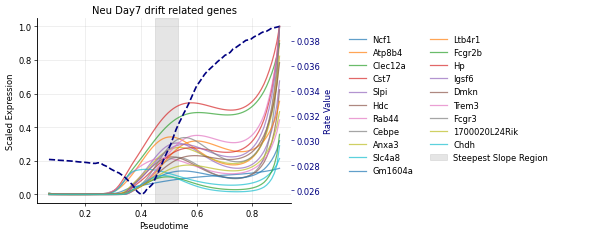

In [327]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_genes_list = sig_genes.index.to_list()
sig_gene_expr = Neu_expr_df.loc[:,sig_genes_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_Day7, 
    lineage='Neu', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_genes_list)//10, frameon=False)
ax1.set_title("Neu Day7 drift related genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Neu_Day7_DEGenes.pdf")

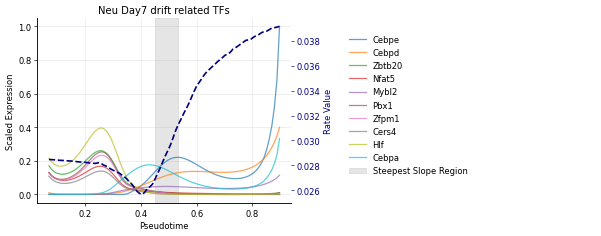

In [331]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = sig_TFs.index.to_list()
sig_gene_expr = Neu_expr_df.loc[:,sig_TFs_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region_Day7, 
    lineage='Neu', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Neu Day7 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Neu_Day7_DETFs.pdf")

# Meg

In [22]:
import de_test

In [ ]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Meg')
# gam_fit = run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
# gam_fit = fitGAM(expression_matrix, cell_time, gene_symbol= genes)
Meg_expr_df = prepare_expression_data(gam_fit, pseudotime=x_project['Meg'])
# Meg_expr_df.to_csv("results/tompos_Meg_GAM/GAM_scaled_expression.csv", index=True)

In [ ]:
print(Meg_expr_df.shape)
Meg_expr_df.head()

(91, 11655)


,Mrpl15,Lypla1,Tcea1,Atp6v1h,Rb1cc1,4732440D04Rik,Pcmtd1,Gm26901,Rrs1,Mybl1,...,mt-Nd4,mt-Nd5,mt-Nd6,mt-Cytb,Vamp7,Tmlhe,Csprs,AC168977.1,AC149090.1,CAAA01118383.1
0.046552,0.063203,0.032094,0.061721,0.037777,0.067075,0.016271,0.076964,0.005288,0.044753,0.004441,...,0.124552,0.108485,0.045056,0.132900,0.038009,0.005249,0.004788,0.007698,0.108151,0.036994
0.052029,0.046918,0.022675,0.045768,0.027025,0.049885,0.010909,0.058232,0.003113,0.032410,0.002561,...,0.095169,0.083207,0.032746,0.101064,0.027182,0.003282,0.002776,0.004852,0.083496,0.026481
0.057506,0.035307,0.016413,0.034425,0.019754,0.037529,0.007552,0.044606,0.001934,0.023923,0.001561,...,0.072491,0.064048,0.024279,0.076284,0.019852,0.002182,0.001699,0.003197,0.064848,0.019413
0.062983,0.027188,0.012332,0.026515,0.014933,0.028823,0.005491,0.034879,0.001318,0.018202,0.001049,...,0.055433,0.049834,0.018565,0.057551,0.014985,0.001580,0.001144,0.002256,0.051020,0.014753
0.068459,0.020035,0.008820,0.019552,0.010759,0.021135,0.003753,0.026248,0.000828,0.013222,0.000645,...,0.040064,0.037068,0.013590,0.040663,0.010771,0.001093,0.000705,0.001483,0.038596,0.010729


## Day 161

In [ ]:
lineage = 'Meg'
day = 161

for day_id in [0,1]:

    day = adata_raw.uns['pop']['t'][day_id]

    steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
    pseudotime_range = (steepest_region[lineage]['start_bin'], 
                    steepest_region[lineage]['end_bin'])
    pseudotime_range = (0.27,0.4)
    # # Run association tests

    print(f"Running association test for {lineage} lineage...")
    test = de_test.AssociationTest(gam_fit, ['lineage'])
    result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
    result_lin_day['gene_symbol'] = gam_fit['gene_symbol']
    # result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

    # select significantly DE genes and annotate TF
    print(f"Selecting significantly DE genes for {lineage} lineage...")
    significant_genes = select_top_de_genes(result_lin_day, qval_threshold=1e-2)
    significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
    significant_genes.set_index("gene_symbol", inplace=True)

    # compute parameter derivative
    print(f"Selecting drift derivative related genes for {lineage} lineage...")
    dx = x_project[lineage][0]
    drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

    # compute correlation and mutual information
    corr_list = [pearsonr(Meg_expr_df[gene].values[10:-3], drift_derivatives[10:-3])[0] for gene in significant_genes.index]
    mi_list = [calculate_mutual_information(Meg_expr_df.loc[:,gene].values[10:-3], drift_derivatives[10:-3]) for gene in significant_genes.index]

    significant_genes['pearson_r'] = corr_list
    significant_genes['mutual_information'] = mi_list

    # significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)

Running association test for Meg lineage...
Selecting significantly DE genes for Meg lineage...
Selecting drift derivative related genes for Meg lineage...


/tmp/ipykernel_1866052/629679835.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]


Running association test for Meg lineage...
Selecting significantly DE genes for Meg lineage...
Selecting drift derivative related genes for Meg lineage...


/tmp/ipykernel_1866052/629679835.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]


<Axes: >

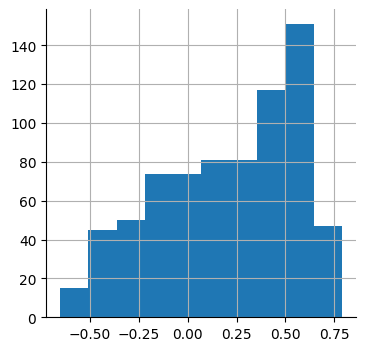

In [98]:
significant_genes['pearson_r'].hist()

### resume

In [31]:
lineage = 'Meg'
day = 161
day_id = 7

# day = adata_raw.uns['pop']['t'][day_id]

steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
pseudotime_range = (steepest_region[lineage]['start_bin'], 
                steepest_region[lineage]['end_bin'])
pseudotime_range = (0.27,0.4)


significant_genes = pd.read_csv("results/tompos_Meg_GAM/Day161_sigDE.csv", index_col=0)
Meg_expr_df = pd.read_csv("results/tompos_Meg_GAM/GAM_scaled_expression.csv", index_col=0).iloc[8:]
Meg_expr_df = scaled_GAM_smooth_expression(Meg_expr_df)

NameError: name 'Meg_sig_genes' is not defined

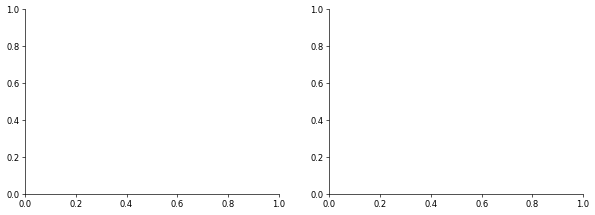

In [32]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_genes_list = Meg_sig_genes.index.to_list()
sig_gene_expr = Meg_expr_df.loc[:,sig_genes_list]#.iloc[10:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Meg', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=(len(sig_genes_list)//10), frameon=False)
ax1.set_title("Meg Day161 drift related genes")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day161_DEgenes.pdf")

In [28]:
Meg_sig_genes = significant_genes.query("`meanLogFC`>2 & `fdr` <1e-3 & `pearson_r` > 0.1 & `mutual_information`>0.4" ).sort_values(["mutual_information"], ascending=False)
print(Meg_sig_genes.shape)

Meg_sig_genes.head(3)

(34, 9)


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Mdm1,11309,26.000328,1.0,3.413594e-07,2.305260,1.849840e-05,False,0.335908,0.857911
P2ry1,3925,24.245354,1.0,8.481142e-07,2.179082,3.969788e-05,False,0.474669,0.830124
Tuba8,8347,46.836707,1.0,7.715466e-12,2.148527,1.362481e-09,False,0.510162,0.785256


In [29]:
Meg_sig_TFs = significant_genes.query("`meanLogFC`>1 & `mutual_information`>0.3 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
print(Meg_sig_TFs.shape)
Meg_sig_TFs.head(3)

(29, 9)


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,
Rb1,13309,12.884791,1.0,3.312631e-04,1.057439,0.006138,True,0.418372,0.897051
Gata1,3031,16.513284,1.0,4.831042e-05,1.219416,0.001247,True,0.641814,0.879422
E2f8,9432,24.989218,1.0,5.765181e-07,1.664518,0.000029,True,0.514437,0.844361


In [34]:
Meg_expr_df.loc[:,sig_TFs_list]

,Gata1,E2f8,Rb1,Ncoa3,Sox6,Sox4,Zfp760,Fos,Cd59a,Ikzf2,Hoxa7,Tfec,Runx2
0.046552,0.000938,0.000997,0.011202,0.041319,0.005696,0.065326,0.018294,0.074373,0.021993,0.062862,0.046877,0.021686,0.035755
0.052029,0.000499,0.000532,0.007268,0.029832,0.003696,0.047908,0.012359,0.059218,0.015081,0.048705,0.034441,0.014818,0.025394
0.057506,0.000286,0.000305,0.004905,0.022041,0.002557,0.035380,0.008593,0.048482,0.010638,0.038765,0.025858,0.010384,0.018398
0.062983,0.000184,0.000197,0.003517,0.016861,0.001922,0.026571,0.006250,0.041024,0.007837,0.031923,0.020050,0.007579,0.013766
0.068459,0.000106,0.000114,0.002364,0.012373,0.001403,0.018805,0.004266,0.034468,0.005455,0.025927,0.014989,0.005189,0.009760
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.517554,0.076960,0.095936,0.057463,0.105716,0.000013,0.019999,0.004056,0.001669,0.011976,0.004575,0.000608,0.004563,0.002919
0.523030,0.076819,0.096512,0.059955,0.109488,0.000009,0.020150,0.004010,0.001180,0.013056,0.003455,0.000908,0.005313,0.002703
0.528507,0.076542,0.097132,0.062889,0.113899,0.000005,0.020394,0.003954,0.000740,0.014249,0.002298,0.001285,0.006294,0.002452
0.533984,0.076127,0.097807,0.066336,0.119040,0.000002,0.020730,0.003887,0.000347,0.015563,0.001136,0.001746,0.007569,0.002167


In [ ]:
sig_gene_expr,
steepest_region
x_project
v_project


In [ ]:
sig_gene_expr.to_csv("results/tompos_Meg_GAM/Fig4g_input.csv")

,Gata1,E2f8,Rb1,Ncoa3,Sox6,Sox4,Zfp760,Fos,Cd59a,Ikzf2,Hoxa7,Tfec,Runx2
0.101320,0.000061,0.000057,0.003662,0.016815,0.016891,0.004743,0.016329,0.240552,0.025507,0.187143,0.071609,0.012675,0.025273
0.106797,0.000027,0.000027,0.002335,0.011990,0.016217,0.001570,0.008312,0.229497,0.015143,0.175806,0.059275,0.005932,0.013807
0.112274,0.000005,0.000007,0.001269,0.007914,0.015842,0.000000,0.002428,0.220761,0.006991,0.167111,0.049767,0.001230,0.005119
0.117750,0.000000,0.000000,0.000613,0.005038,0.015990,0.001291,0.000115,0.215945,0.002460,0.162905,0.045032,0.000000,0.001116
0.123227,0.000006,0.000002,0.000188,0.002843,0.016485,0.004489,0.000000,0.213539,0.000079,0.161482,0.043236,0.000958,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.517554,0.999819,0.973450,0.815975,0.845198,0.000402,0.112459,0.201258,0.021567,0.539358,0.072785,0.012975,0.163678,0.080740
0.523030,0.997989,0.979296,0.851365,0.875356,0.000273,0.113311,0.199005,0.015256,0.588024,0.054959,0.019375,0.190550,0.074771
0.528507,0.994395,0.985582,0.893036,0.910618,0.000165,0.114680,0.196206,0.009567,0.641767,0.036558,0.027404,0.225745,0.067827
0.533984,0.989003,0.992428,0.941984,0.951720,0.000075,0.116570,0.192874,0.004479,0.700925,0.018071,0.037236,0.271472,0.059926


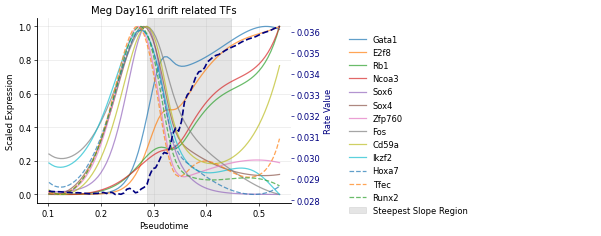

In [39]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = Meg_sig_TFs.index.to_list()
sig_TFs_list = ['Gata1', 'E2f8', 'Rb1', 'Ncoa3', 'Sox6', 'Sox4', 'Zfp760', 'Fos', 'Cd59a', 'Ikzf2', 'Hoxa7', 'Tfec', 'Runx2']
sig_gene_expr = Meg_expr_df.loc[:,sig_TFs_list].iloc[10:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Meg', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Meg Day161 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day161_DETFs.pdf")

In [ ]:
TF_groups = {
    'group1': ['Sox6', 'Sox4', 'Cd59a', ,'Fos', 'Ikzf2', 'Hoxa7', 'Tfec', 'Runx2'],
    'group2': ['Gata1', 'TF2'],
    'group3': ['TF1', 'TF2'],
}

## Meg Day 12

### resume

In [33]:
lineage = 'Meg'
day = 12
day_id = 2

# day = adata_raw.uns['pop']['t'][day_id]

steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
pseudotime_range = (steepest_region[lineage]['start_bin'], 
                steepest_region[lineage]['end_bin'])
pseudotime_range = (0.27,0.4)


significant_genes = pd.read_csv("results/tompos_Meg_GAM/Day12_sigDE.csv", index_col=0)
Meg_expr_df = pd.read_csv("results/tompos_Meg_GAM/GAM_scaled_expression.csv", index_col=0).iloc[8:]
Meg_expr_df = scaled_GAM_smooth_expression(Meg_expr_df)

In [34]:
significant_genes['fdr'] = multipletests(significant_genes['pvalue'], method='fdr_bh')[1]

In [35]:
Meg_sig_genes = significant_genes.query("`meanLogFC`>2 & `fdr` <1e-3 & `pearson_r` > 0.1 & `mutual_information`>0.4" ).sort_values(["mutual_information"], ascending=False)
print(Meg_sig_genes.shape)

Meg_sig_genes.head(3)

(124, 9)


,gene,waldStat,df,pvalue,meanLogFC,is_TF,pearson_r,mutual_information,fdr
gene_symbol,,,,,,,,,
Gata1,3031,38.082464,1.0,6.781691e-10,3.373652,True,0.396980,1.152664,1.025731e-08
2610318N02Rik,19244,14.396017,1.0,1.481153e-04,3.325605,False,0.161431,1.142011,3.882010e-04
C330027C09Rik,19590,12.535380,1.0,3.993184e-04,2.973799,False,0.364694,1.131063,8.589782e-04


In [36]:
Meg_sig_TFs = significant_genes.query("`meanLogFC`>1 & `mutual_information`>0.3 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
print(Meg_sig_TFs.shape)
Meg_sig_TFs.head(3)

(47, 9)


,gene,waldStat,df,pvalue,meanLogFC,is_TF,pearson_r,mutual_information,fdr
gene_symbol,,,,,,,,,
Gata1,3031,38.082464,1.0,6.781691e-10,3.373652,True,0.396980,1.152664,1.025731e-08
Rb1,13309,18.714997,1.0,1.517840e-05,1.608085,True,0.120976,1.111229,5.924472e-05
Ncoa3,2807,29.516405,1.0,5.544541e-08,1.332785,True,0.097115,1.074672,4.913063e-07


In [ ]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = Meg_sig_TFs.index.to_list()
sig_TFs_list = ['Pf4','Mybl2', 'E2f8', 'Foxm1', 'Anxa1', 'Mxd3', 'Gata1', 'E2f7', 'Irf1', 'Brca1', 'Kif22', 'Egr1', 'Hoxa9']
sig_gene_expr = Meg_expr_df.loc[:,sig_TFs_list]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Meg', 
    day_idx=1,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Meg Day12 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day12_DETFs.pdf")

In [40]:
TF_groups = {
    'TF-group1': ["Hoxa9", "Egr1", "Irf1", "Anxa1"],
    'TF-group3': ["Mxd3", "Foxm1"],
    'TF-group2': ["E2f8", "Brca1", "Mybl2", "E2f7"],
    }

In [41]:
v_project['Meg'][2].shape

(99,)

In [42]:
steepest_region['Meg']

{'start_bin': 0.282053006246055,
 'end_bin': 0.44087897092829953,
 'mean_slope': 0.033018228,
 'window_idx': (51, 81)}

In [45]:
x_project['Meg'].shape

(99,)

In [ ]:
np.argmin((x_project['Meg'] - 0.27)**2)
np.argmin((x_project['Meg'] - 0.4)**2)

(49, 73)

In [59]:
x_project['Meg'][[0, 20, 40,60,80]]

array([0.00273838, 0.11227353, 0.22180867, 0.33134382, 0.44087897])

In [ ]:
# only this range of pseudotime is displayed
meg_pdt = x_project['Meg'][18:]

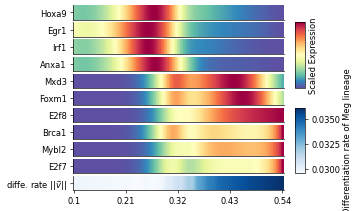

In [86]:
# ... existing code ...
dpi = 60

# only this range of pseudotime is displayed
meg_pdt = x_project['Meg'][18:]

# starting bin of fast changing region
grid_i = np.argmin(( meg_pdt - 0.27 ) **2 ) 
grid_j = np.argmin((meg_pdt - 0.4)**2)

# Use GridSpec for better layout control
fig = plt.figure(figsize=(5, 4), dpi=dpi)
gs = fig.add_gridspec(11, 2, width_ratios=[1, 0.05], hspace=0.2, wspace=0.1)

# Create axes for the heatmaps
axs = []
for i in range(10):  # First 10 axes for TFs
    ax = fig.add_subplot(gs[i, 0])
    axs.append(ax)

# Last axis for differentiation rate
ax_diff = fig.add_subplot(gs[10, 0])
axs.append(ax_diff)

# Shared colorbar for TFs (first 10 plots)
cax1 = fig.add_subplot(gs[1:5, 1])

# Colorbar for differentiation rate
cax2 = fig.add_subplot(gs[6:10, 1])

i = 0
tf_images = []

for group, TFs in TF_groups.items():
    for tf in TFs:
        tf_gam = axs[i].imshow(Meg_expr_df[tf].values[10:].reshape(1,-1), aspect='auto')
        tf_images.append(tf_gam)
        
        axs[i].set_xticks([])
        axs[i].set_yticks([0])
        axs[i].set_yticklabels([tf])
        i += 1

# Add shared colorbar for TFs without ticks
tf_cbar = fig.colorbar(tf_images[0], cax=cax1)
tf_cbar.set_ticks([])
tf_cbar.ax.set_ylabel("Scaled Expression")

# Plot differentiation rate
v = axs[-1].imshow(v_project['Meg'][2][18:].reshape(1,-1), aspect='auto', cmap='Blues')
axs[-1].set_xticks([0, 20, 40, 60, 80])
axs[-1].set_yticks([0])
axs[-1].set_yticklabels(["diffe. rate "+r"$||\vec{v}||$"])
axs[-1].set_xticklabels(np.around(meg_pdt[[0, 20, 40, 60, 80]], 2))
axs[-1].set_label("Pseudotime")

# Add colorbar for differentiation rate with ticks
v_cbar = fig.colorbar(v, cax=cax2)
v_cbar.ax.set_ylabel("Differentiation rate of Meg lineage")


if dpi == 600:
    fig.savefig("figures/tompos_tradeseq/Meg_Day12_TF_module_heatmap.pdf", bbox_inches='tight')
# ... existing code ...

# Ery

In [ ]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Ery')
gam_fit_Ery = run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
GAMfit_dict['Ery'] = gam_fit_Ery.copy()

# Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'][8:])
# Ery_expr_df.to_csv("results/tompos_Ery_GAM/GAM_scaled_expression.csv", index=True)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [ ]:
expression_matrix, cell_time, genes = get_input(adata_lin, 'Ery')
gam_fit_Ery = de_test.run_fitGAM_parallel(expression_matrix, cell_time, genes, n_cores=10)
GAMfit_dict['Ery'] = gam_fit_Ery.copy()

Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'])
# Ery_expr_df.to_csv("results/tompos_Ery_GAM/GAM_scaled_expression.csv", index=True)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [242]:
Ery_expr_df = prepare_expression_data(gam_fit_Ery, pseudotime=x_project['Ery'])

In [241]:
cell_time.min(), cell_time.max()

(0.13948978097419001, 0.8806194861629267)

In [224]:
pseudotime_range

(0.16273311392683998, 0.43240513129131775)

In [226]:
pseudotime_range = (steepest_region[lineage]['start_bin'], 
                    steepest_region[lineage]['end_bin'])

In [227]:
pseudotime_range

(0.12008447538585365, 0.378043718807317)

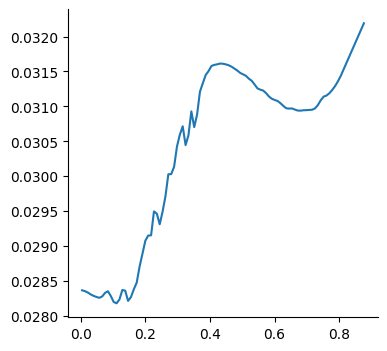

In [257]:
plt.plot(x_project['Ery'], v_project['Ery'][1])

In [258]:
lineage = 'Ery'

for day_id in [0,1,7]:

    day = adata_raw.uns['pop']['t'][day_id]

    steepest_region = find_steepest_region(x_project, v_project, day_id, min_bins=30)
    pseudotime_range = (0.2, 
                    steepest_region[lineage]['end_bin'])
    # # Run association tests

    print(f"Running association test for {lineage} lineage...")
    test = de_test.AssociationTest(gam_fit_Ery, ['lineage'])
    result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
    result_lin_day['gene_symbol'] = gam_fit_Ery['gene_symbol']
    result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

    # select significantly DE genes and annotate TF
    print(f"Selecting significantly DE genes for {lineage} lineage...")
    significant_genes = select_top_de_genes(result_lin_day, qval_threshold=1e-2)
    significant_genes['is_TF'] = significant_genes['gene_symbol'].isin(mmTF['gene_symbol'])
    significant_genes.set_index("gene_symbol", inplace=True)

    # compute parameter derivative
    print(f"Selecting drift derivative related genes for {lineage} lineage...")
    dx = x_project[lineage][0]
    drift_derivatives = np.gradient(v_project[lineage][day_id], dx)

    # compute correlation and mutual information
    corr_list = [pearsonr(Ery_expr_df[gene].values[:-3], drift_derivatives[8:-3])[0] for gene in significant_genes.index]
    mi_list = [calculate_mutual_information(Ery_expr_df.loc[:,gene].values[:-3], drift_derivatives[8:-3]) for gene in significant_genes.index]

    significant_genes['pearson_r'] = corr_list
    significant_genes['mutual_information'] = mi_list

    significant_genes.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_sigDE.csv", index=True)

Running association test for Ery lineage...
Selecting significantly DE genes for Ery lineage...
Selecting drift derivative related genes for Ery lineage...


/tmp/ipykernel_1866052/629679835.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['fdr'] = multipletests(significant['pvalue'], method='fdr_bh')[1]


ValueError: x and y must have the same length.

In [253]:
print(f"Running association test for {lineage} lineage...")
test = de_test.AssociationTest(gam_fit_Ery, ['lineage'])
result_lin_day = test.association_test(restrcited_pseudotime=pseudotime_range)
result_lin_day['gene_symbol'] = gam_fit_Ery['gene_symbol']
# result_lin_day.to_csv(f"results/tompos_{lineage}_GAM/Day{day}_associationtest.csv", index=False)

Running association test for Ery lineage...
Error processing gene 4: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 5: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 7: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 10: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 12: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 13: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene 16: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
Error processing gene

In [229]:
Ery_sig_gene_df = significant_genes
print(Ery_sig_gene_df.shape)
Ery_sig_gene_df.head()

(0, 9)


,gene,waldStat,df,pvalue,meanLogFC,fdr,is_TF,pearson_r,mutual_information
gene_symbol,,,,,,,,,


array([[<Axes: title={'center': 'pearson_r'}>,
        <Axes: title={'center': 'mutual_information'}>]], dtype=object)

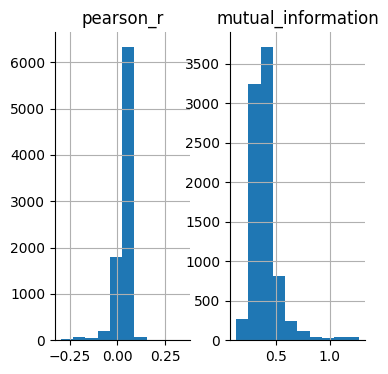

In [197]:
Ery_sig_gene_df[['pearson_r','mutual_information']].hist()

In [201]:
Ery_sig_TFs = Ery_sig_gene_df.query("`pearson_r` > 0.05 & `mutual_information`>0.4 & `is_TF` == True" ).sort_values("mutual_information", ascending=False)
print(Ery_sig_TFs.shape)

(14, 9)


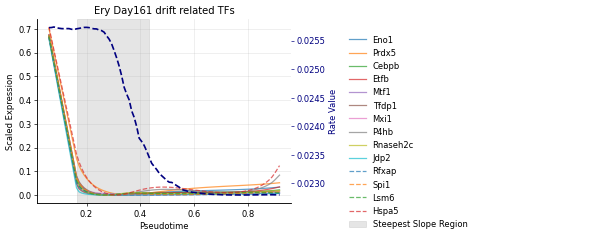

In [212]:
dpi = 60
fig, axs = plt.subplots(1,2, figsize=(12, 4), dpi=dpi, frameon=False)


sig_TFs_list = Ery_sig_TFs.index.to_list()
sig_gene_expr = Ery_expr_df.loc[:,sig_TFs_list].iloc[6:]
ax1, ax2 = plot_de_genes_with_rate(
    sig_gene_expr, 
    steepest_region, 
    lineage='Ery', 
    day_idx=8,
    v_project=v_project,  # Assuming this is available from notebook
    x_project=x_project,
    ax = axs[0]
    )

axs[1].axis("off")
ax1.legend(bbox_to_anchor=(1.2, 0.95), loc='upper left', ncol=len(sig_TFs_list)//10, frameon=False)
ax1.set_title("Ery Day161 drift related TFs")

if dpi==600:
    fig.savefig("figures/tompos_tradeseq/Ery_Day161_DETFs.pdf")